In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
idx = "0"
# type = "1000/90_90_5"
type = "no_ti/0"
# type = "1000/90_90_130"

In [3]:
voltage = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{type}/voltage.csv", index_col = 0)

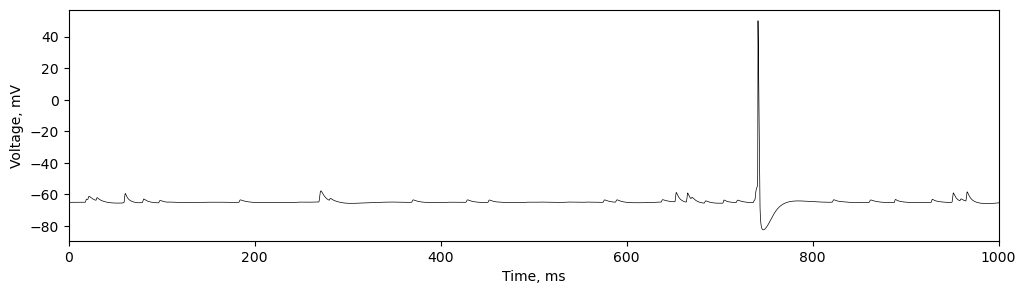

In [4]:
plt.figure(figsize = (12, 3))
plt.plot(
    voltage.Time,
    voltage.Voltage,
    linewidth = 0.5,
    color = "black"
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")

# plt.xlim(300000 - 10000, 300000)
plt.xlim(0, 1000)

plt.show()

In [5]:
spike_frequency = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{type}/spike_frequency.csv")

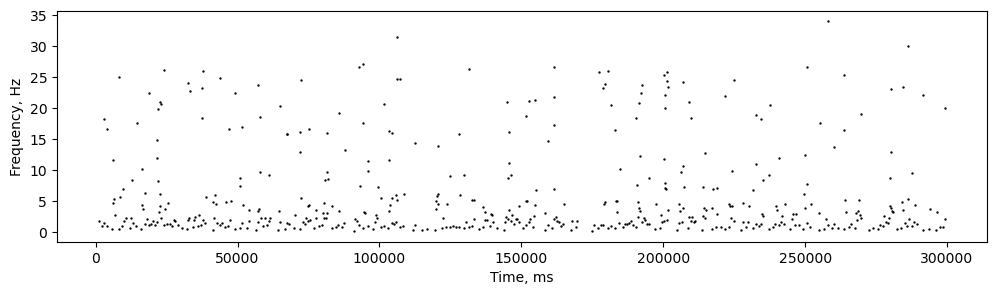

In [6]:
plt.figure(figsize = (12, 3))
plt.scatter(
    spike_frequency.Time,
    spike_frequency.Frequency,
    s = 0.5,
    color = "black"
)

plt.xlabel("Time, ms")
plt.ylabel("Frequency, Hz")

plt.show()

In [7]:
weights = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{type}/synapse_weights.csv")

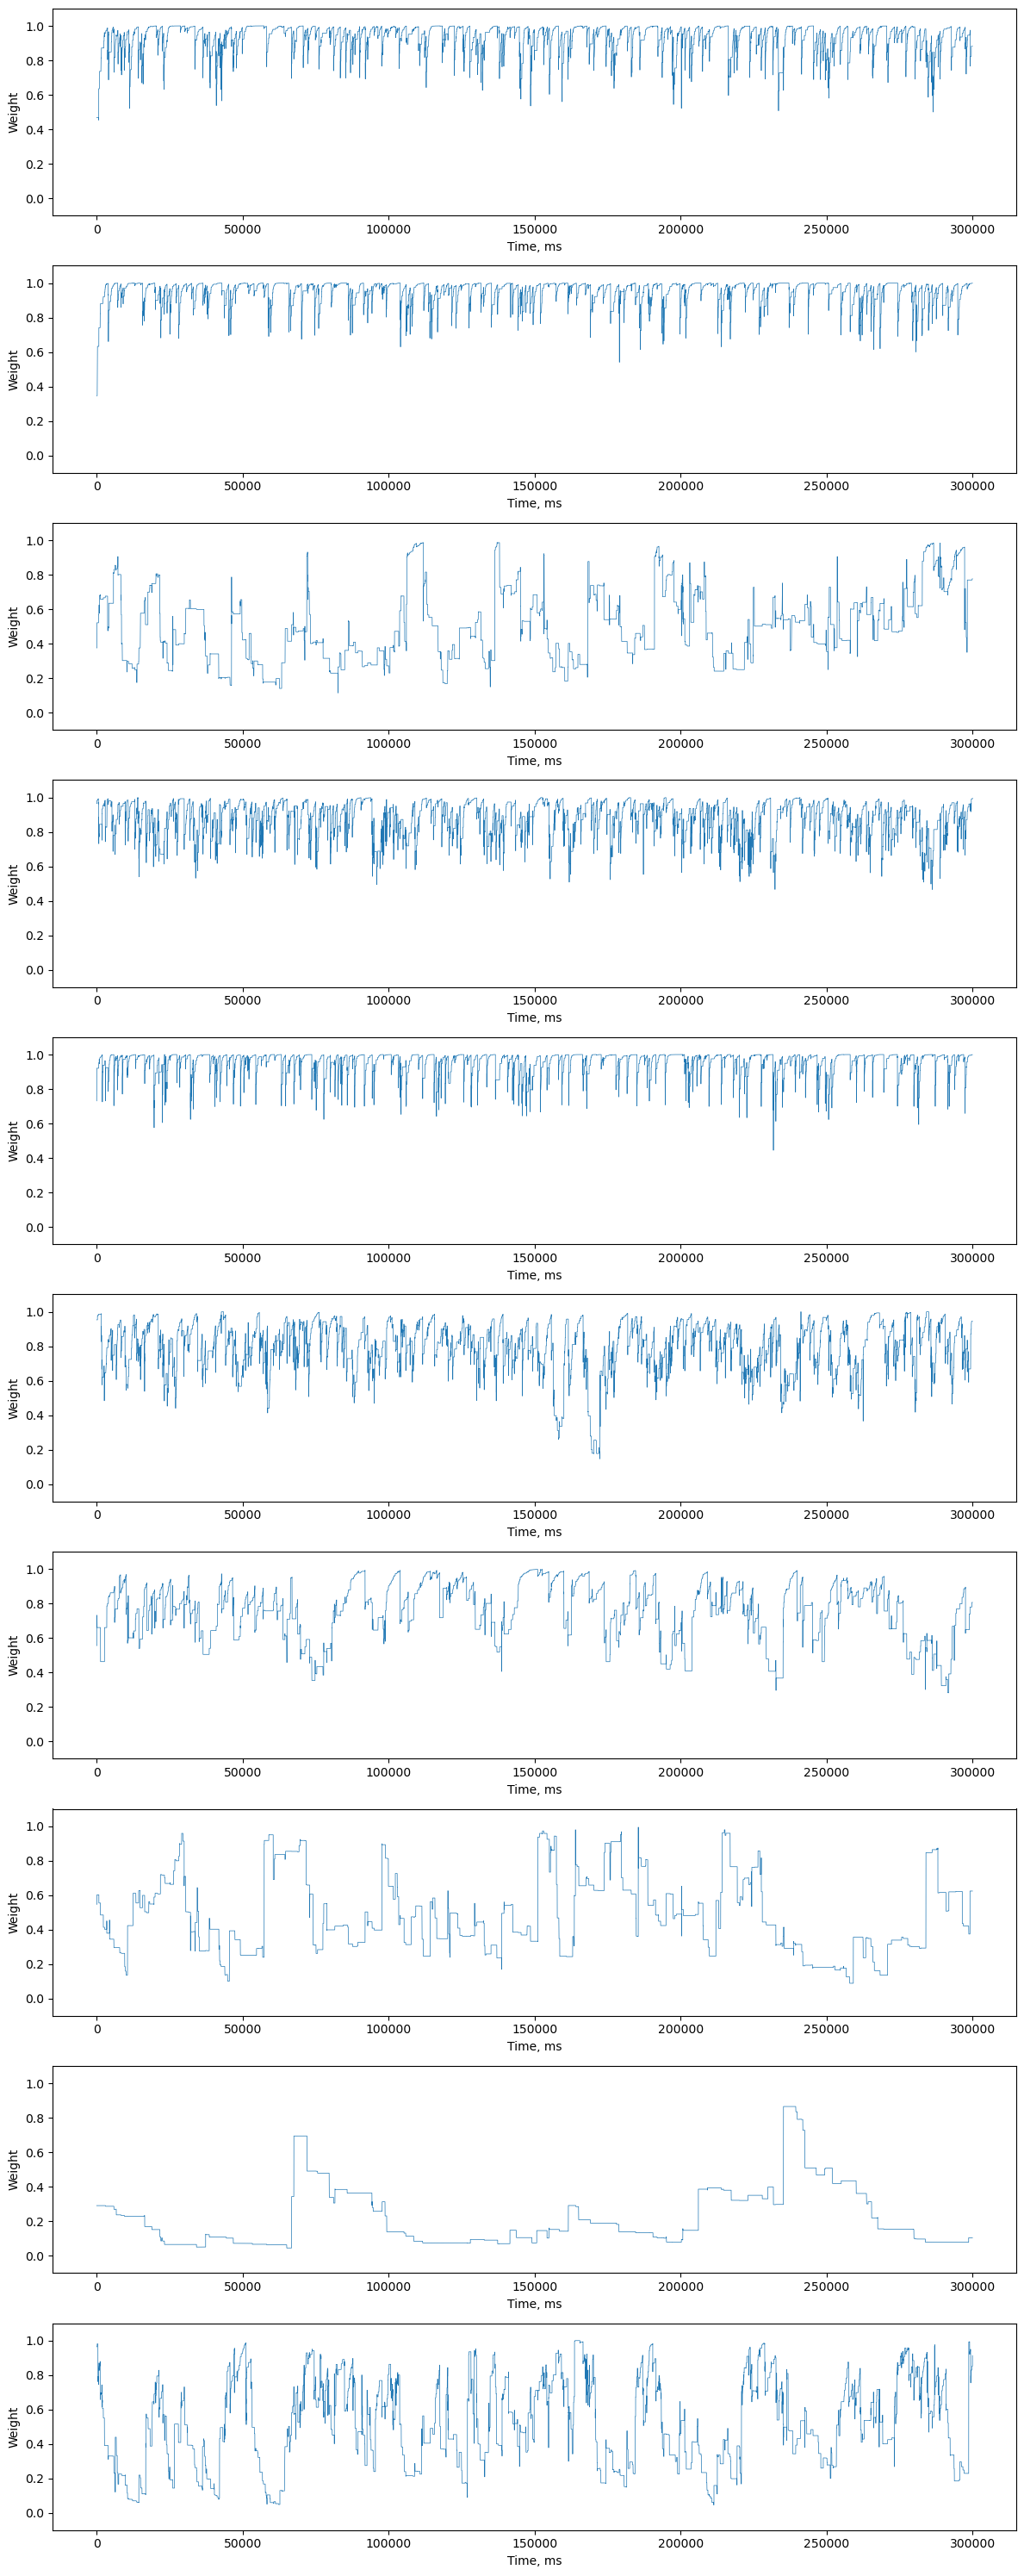

In [8]:
fig, axs = plt.subplots(nrows = 10, ncols = 1, figsize = (12, 30))

for i in range(0, 10):
    axs[i].plot(weights.Time, weights[f"Synapse{i}"], linewidth = 0.5)
    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Weight")
    axs[i].set_ylim(-0.1, 1.1)
    # axs[i].set_xlim(0, 60 * 1000)

fig.tight_layout()
plt.show()

# What are we interested in?

- Interspike intervals?
- Overall spike frequency rate?
- Synaptic weight distribution - final and throughout the recording? It seems that fully potentiated weights seem to stay potentiated, while others display some dynamics.
- Is it safe to drop the voltage?.. Maybe I don't really need it.
- Ahh I'm very interested to see what would happen to the orientation in another direction. I don't think I have enough time to run all the simulations I would like. Maybe talk with Aušra?
- Plan the other simulations.

TODO: 
- Calculate spike times and interspike intervals. Plot comparing the three.
- Google what others do with the synaptic weights, unsure how to proceed as is.


## Interspike intervals

In [9]:
def get_spike_frequency(idx, type):
    return pd.read_csv(f"output/temporal-interference/poisson/{idx}/{type}/spike_frequency.csv")

In [10]:
def calculate_spike_times(idx, type):
    spike_frequency = get_spike_frequency(idx, type)

    spike_times = spike_frequency.Time.values
    np.insert(spike_times, 0, spike_frequency.Time[0] - 1000 / spike_frequency.Frequency[0])
    
    return spike_times

In [11]:
def calculate_isi(idx, type):
    spike_times = calculate_spike_times(idx, type)
    
    return np.diff(spike_times)

In [12]:
isi_no_ti = calculate_isi(idx, "no_ti/0")
isi_ti_5 = calculate_isi(idx, "1000/90_90_5")
isi_ti_130 = calculate_isi(idx, "1000/90_90_130")

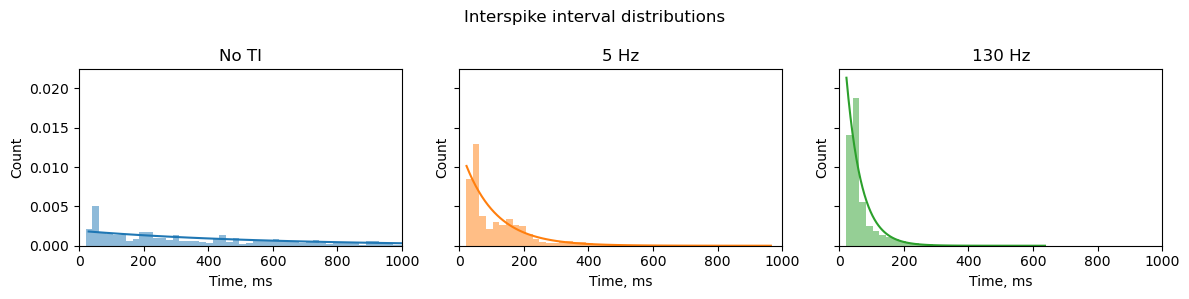

In [43]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey = True)

min = 0
max = np.max([isi_no_ti.max(), isi_ti_5.max(), isi_ti_130.max()])

bin_edges = np.linspace(min, max, num = 250)

labels = [
    "No TI",
    "5 Hz",
    "130 Hz"
]

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green"
]

for i, isi in enumerate([isi_no_ti, isi_ti_5, isi_ti_130]):
    loc, scale = stats.expon.fit(isi)

    x = np.linspace(isi.min(), isi.max(), 100)
    pdf_fitted = stats.expon.pdf(x, loc, scale)

    axs[i].hist(isi, bins = bin_edges, density = True, alpha = 0.5, label = labels[i], color = colors[i])
    axs[i].plot(x, pdf_fitted, color = colors[i])

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Count")
    axs[i].set_title(labels[i])
    axs[i].set_xlim(0, 1000)

fig.suptitle("Interspike interval distributions")
fig.tight_layout()
plt.show()

### There is a significant difference between the ISI distributions:

In [14]:
_, p_value = stats.ks_2samp(isi_no_ti, isi_ti_5)
print(f"KS Test p-value TI vs 5 Hz: {p_value:.4f}")

_, p_value = stats.ks_2samp(isi_no_ti, isi_ti_130)
print(f"KS Test p-value TI vs 130 Hz: {p_value:.4f}")

_, p_value = stats.ks_2samp(isi_ti_5, isi_ti_130)
print(f"KS Test p-value 5 Hz vs 130 Hz: {p_value:.4f}")

KS Test p-value TI vs 5 Hz: 0.0000
KS Test p-value TI vs 130 Hz: 0.0000
KS Test p-value 5 Hz vs 130 Hz: 0.0000


### But the fit is definitely not exponential

In [15]:
# Does the fit fit the data?
loc, scale = stats.expon.fit(isi_no_ti)
stat, p_value = stats.kstest(isi_no_ti, 'expon', args=(loc, scale))
print(f"KS statistic = {stat:.4f}, p-value = {p_value:.4f}")

loc, scale = stats.expon.fit(isi_ti_5)
stat, p_value = stats.kstest(isi_ti_5, 'expon', args=(loc, scale))
print(f"KS statistic = {stat:.4f}, p-value = {p_value:.4f}")

loc, scale = stats.expon.fit(isi_ti_130)
stat, p_value = stats.kstest(isi_ti_130, 'expon', args=(loc, scale))
print(f"KS statistic = {stat:.4f}, p-value = {p_value:.4f}")

KS statistic = 0.1013, p-value = 0.0001
KS statistic = 0.1163, p-value = 0.0000
KS statistic = 0.1384, p-value = 0.0000


### Is it gamma?

In [16]:
shape, loc, scale = stats.gamma.fit(isi_no_ti, floc = 0)
# pdf = stats.gamma.pdf(np.sort(isi_no_ti), shape, loc, scale)

ks_stat, p_value = stats.kstest(isi_no_ti, 'gamma', args=(shape, loc, scale))
print(f"KS statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")

KS statistic = 0.0601, p-value = 0.0481


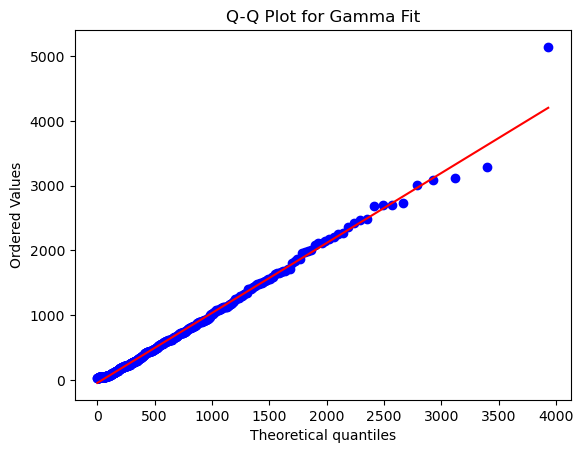

In [17]:
stats.probplot(isi_no_ti, dist="gamma", sparams=(shape, loc, scale), plot=plt)
plt.title("Q-Q Plot for Gamma Fit")
plt.show()

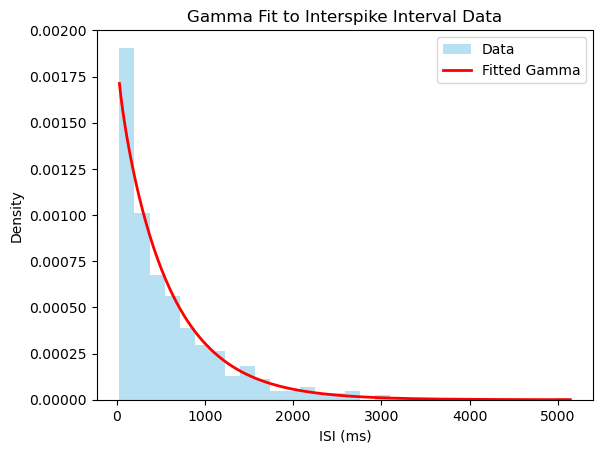

In [18]:
# Fit the gamma distribution
shape, loc, scale = stats.gamma.fit(isi_no_ti, floc = 0)

# Create x values for plotting the PDF
x = np.linspace(np.min(isi_no_ti), np.max(isi_no_ti), 1000)
pdf = stats.gamma.pdf(x, shape, loc = loc, scale = scale)

# Plot histogram of your data
plt.hist(isi_no_ti, bins=30, density=True, alpha=0.6, color='skyblue', label='Data')

# Plot the fitted gamma PDF
plt.plot(x, pdf, 'r-', linewidth=2, label='Fitted Gamma')

# Labels and legend
plt.xlabel("ISI (ms)")
plt.ylabel("Density")
plt.title("Gamma Fit to Interspike Interval Data")
plt.legend()
plt.show()

### Looks beautiful, is not gamma

### Is it Weibull?

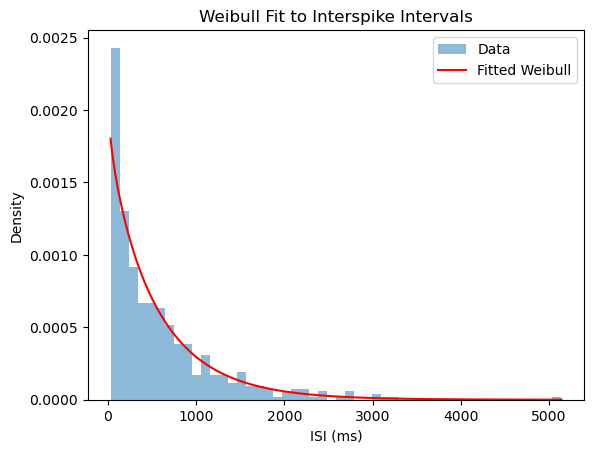

In [19]:
# Fit the Weibull distribution
shape, loc, scale = stats.weibull_min.fit(isi_no_ti, floc=0)  # force loc=0 is often reasonable for ISIs

# Create x-values for the PDF
x = np.linspace(np.min(isi_no_ti), np.max(isi_no_ti), 1000)
pdf = stats.weibull_min.pdf(x, shape, loc, scale)

# Plot
plt.hist(isi_no_ti, bins=50, density=True, alpha=0.5, label='Data')
plt.plot(x, pdf, 'r-', label='Fitted Weibull')
plt.xlabel("ISI (ms)")
plt.ylabel("Density")
plt.title("Weibull Fit to Interspike Intervals")
plt.legend()
plt.show()

In [20]:
ks_stat, p_value = stats.kstest(isi_no_ti, 'weibull_min', args=(shape, loc, scale))
print(f"KS statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")

KS statistic = 0.0644, p-value = 0.0276


In [21]:
log_likelihood = np.sum(stats.weibull_min.logpdf(isi_no_ti, shape, loc, scale))
k = 2  # shape and scale (loc was fixed)
AIC_weibull = 2 * k - 2 * log_likelihood
print(f"AIC (Weibull) = {AIC_weibull}")

AIC (Weibull) = 7532.469486846761


In [22]:
# Fit gamma
shape, loc, scale = stats.gamma.fit(isi_no_ti, floc=0)  # often fix loc=0 for ISI

# Log-likelihood
log_likelihood = np.sum(stats.gamma.logpdf(isi_no_ti, shape, loc, scale))

# AIC: gamma has 2 parameters here (shape, scale)
k = 2
AIC_gamma = 2 * k - 2 * log_likelihood
print(f"AIC (Gamma) = {AIC_gamma:.2f}")

AIC (Gamma) = 7533.92


### log normal

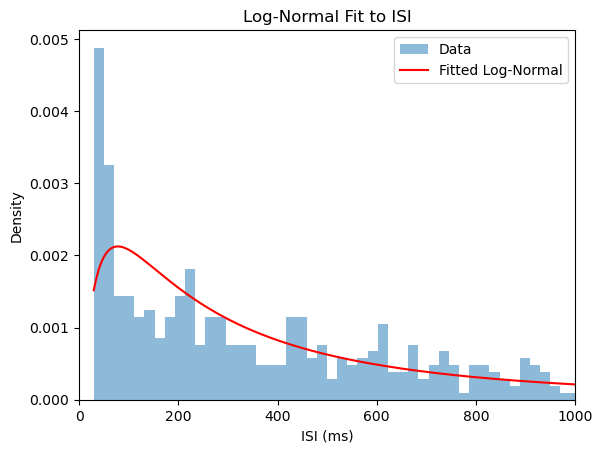

In [23]:
shape, loc, scale = stats.lognorm.fit(isi_no_ti, floc = 0)

x = np.linspace(np.min(isi_no_ti), np.max(isi_no_ti), 1000)
pdf = stats.lognorm.pdf(x, shape, loc, scale)

plt.hist(isi_no_ti, bins=250, density=True, alpha=0.5, label='Data')
plt.plot(x, pdf, 'r-', label='Fitted Log-Normal')
plt.xlabel("ISI (ms)")
plt.ylabel("Density")
plt.title("Log-Normal Fit to ISI")
plt.legend()
plt.xlim(0, 1000)
plt.show()

In [24]:
ks_stat, p_value = stats.kstest(isi_no_ti, 'lognorm', args=(shape, loc, scale))
print(f"KS statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")

KS statistic = 0.0745, p-value = 0.0065


In [25]:
log_likelihood = np.sum(stats.lognorm.logpdf(isi_no_ti, shape, loc, scale))
k = 2  # shape and scale (loc fixed)
AIC_lognorm = 2 * k - 2 * log_likelihood
print(f"AIC (Log-Normal) = {AIC_lognorm:.2f}")

AIC (Log-Normal) = 7526.19


In [26]:
spike_times_no = calculate_spike_times(idx, "no_ti/0")
spike_times_5 = calculate_spike_times(idx, "1000/90_90_5")
spike_times_130 = calculate_spike_times(idx, "1000/90_90_130")

## Spike times and firing frequency

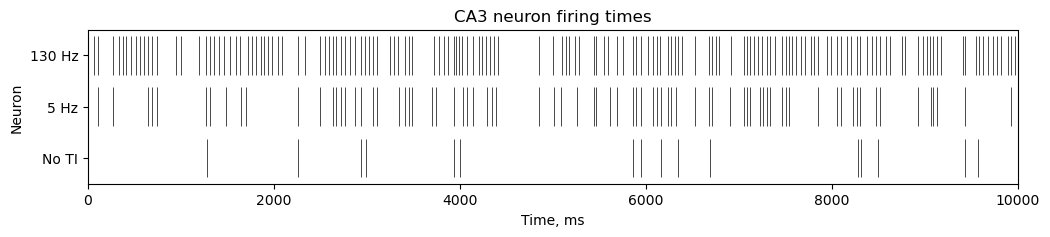

In [27]:
plt.figure(figsize = (12, 2))

for i, spike_times in enumerate([spike_times_no, spike_times_5, spike_times_130]):
    plt.eventplot(spike_times, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, 3.5)
plt.ylabel("Neuron")
plt.yticks(np.arange(1, 4, 1), ["No TI", "5 Hz", "130 Hz"])

plt.xlabel("Time, ms")
plt.xlim(0, 10000)

plt.title("CA3 neuron firing times")
plt.show()

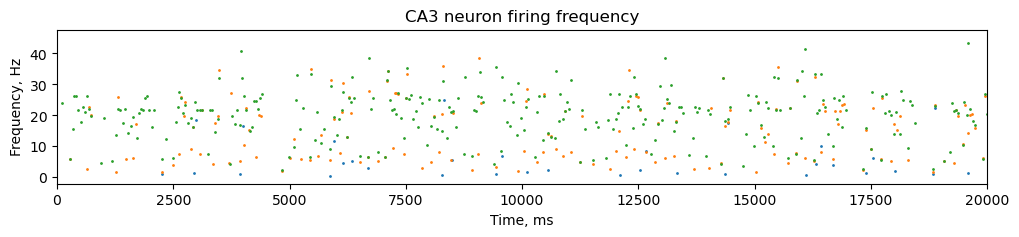

In [28]:
plt.figure(figsize = (12, 2))

for i, spike_times in enumerate([spike_times_no, spike_times_5, spike_times_130]):
    time = spike_times[1:]
    isi = np.diff(spike_times)
    instantaneous_freq = 1000 / isi
    plt.scatter(time, instantaneous_freq, s = 1, color = colors[i])

plt.ylabel("Frequency, Hz")

plt.xlabel("Time, ms")
plt.xlim(0, 20000)

plt.title("CA3 neuron firing frequency")
plt.show()

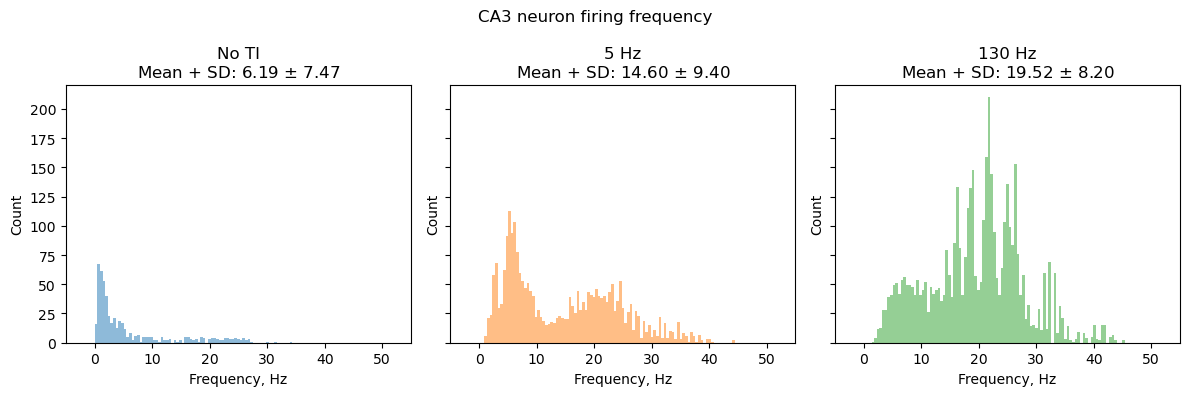

In [29]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4), sharey = True)

spike_freq_no = get_spike_frequency(idx, "no_ti/0").Frequency
spike_freq_5 = get_spike_frequency(idx, "1000/90_90_5").Frequency
spike_freq_130 = get_spike_frequency(idx, "1000/90_90_130").Frequency

min = 0
max = np.max([spike_freq_no.max(), spike_freq_5.max(), spike_freq_130.max()])

bin_edges = np.linspace(min, max, num = 100)

labels = [
    "No TI",
    "5 Hz",
    "130 Hz"
]

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green"
]

for i, spike_freq in enumerate([spike_freq_no, spike_freq_5, spike_freq_130]):
    axs[i].hist(spike_freq, bins = bin_edges, alpha = 0.5, color = colors[i])
    axs[i].set_ylabel("Count")
    axs[i].set_xlabel("Frequency, Hz")
    axs[i].set_xlim(-5, 55)
    axs[i].set_title(f"{labels[i]}" + "\n" + fr"Mean + SD: {np.mean(spike_freq):.2f} $\pm$ {np.std(spike_freq):.2f}")

fig.suptitle("CA3 neuron firing frequency")
fig.tight_layout()
plt.show()

## Dynamics of the synaptic weights

- Cluster synaptic weights (expecting two or three clusters)
- What determines the evolution of the synaptic weights?
    - Synapse location (proximal vs distal)
    - Input spike timing / frequency
    - Local membrane voltage at the synapse ---- this i don't have.
    - Initial weight value

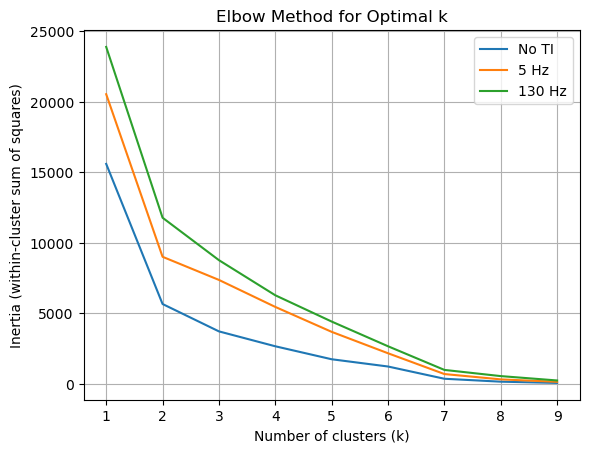

In [30]:
from sklearn.cluster import KMeans

labels = [
    "No TI",
    "5 Hz",
    "130 Hz"
]

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green"
]

for i, filetype in enumerate(["no_ti/0", "1000/90_90_5", "1000/90_90_130"]):
    syn_weights = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{filetype}/synapse_weights.csv")

    trajectories = np.array([syn_weights[f"Synapse{i}"] for i in range(10)])
    
    inertia = []
    k_range = range(1, 10)
    
    for k in k_range:
        kmeans = KMeans(n_clusters = k, random_state = 0).fit(trajectories)
        inertia.append(kmeans.inertia_)

    plt.plot(k_range, inertia, color = colors[i], label = labels[i])

plt.legend()
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

In [31]:
opt_k = 2
trajectories = np.array([weights[f"Synapse{i}"] for i in range(10)])
kmeans = KMeans(n_clusters = opt_k, random_state = 0).fit(trajectories)

kmeans.labels_

array([0, 0, 1, 0, 0, 0, 0, 1, 1, 1], dtype=int32)

In [32]:
synapse_info = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{type}/synapse_info.csv", index_col = 0)

Is location along the dendrite related to the synapse dynamics? Yes.

In [33]:
r, p = stats.pearsonr(synapse_info.Location, kmeans.labels_)
print(f"Correlation: r = {r:.2f}, p = {p:.4f}")

Correlation: r = -0.80, p = 0.0054


Is dendrite related to the synapse dynamics? No.

In [34]:
r, p = stats.pearsonr(synapse_info.Dendrite, kmeans.labels_)
print(f"Correlation: r = {r:.2f}, p = {p:.4f}")

Correlation: r = -0.04, p = 0.9163


Is distance from the soma related to the synapse dynamics? Not really.

In [35]:
r, p = stats.pearsonr(synapse_info.Distance, kmeans.labels_)
print(f"Correlation: r = {r:.2f}, p = {p:.4f}")

Correlation: r = -0.58, p = 0.0780


Is initial weight related to the synapse dynamics? Yes.

In [36]:
r, p = stats.pearsonr(synapse_info.InitialWeight, kmeans.labels_)
print(f"Correlation: r = {r:.2f}, p = {p:.4f}")

Correlation: r = -0.63, p = 0.0509


So it seems that both the dendritic location and the initial weight contribute to the synapse dynamics. Which is more important?

Do synapses belong to the same k-means cluster (aka do they follow similar dynamics) under different conditions?

Mostly yes (in run 9, all match; in other runs (that I checked), almost all match -- and the unmatched ones are just confusing).

In [37]:
opt_k = 2

klabels = []

for i, filetype in enumerate(["no_ti/0", "1000/90_90_5", "1000/90_90_130"]):
    syn_weights = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{filetype}/synapse_weights.csv")

    trajectories = np.array([syn_weights[f"Synapse{i}"] for i in range(10)])

    kmeans = KMeans(n_clusters = opt_k, random_state = 347685).fit(trajectories)

    klabels.append(kmeans.labels_)

klabels = np.vstack(klabels)

In [38]:
klabels

array([[0, 0, 1, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 1, 0, 0, 0, 1, 1, 1, 1],
       [0, 0, 1, 0, 0, 0, 1, 1, 1, 0]], dtype=int32)

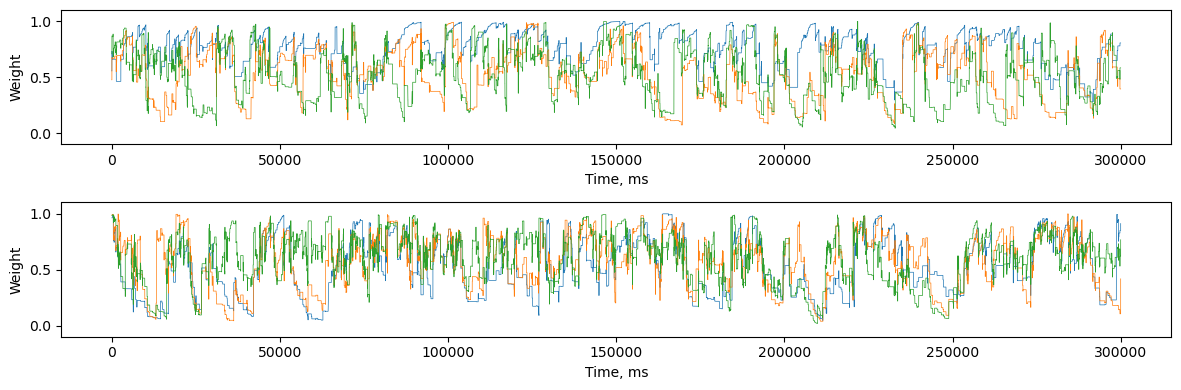

In [39]:
totals = klabels.sum(axis = 0)
different = np.where(np.logical_and(totals != 0, totals != 3))[0]

# different = np.arange(0, 10)

fig, axs = plt.subplots(nrows = len(different), ncols = 1, figsize = (12, 2 * len(different)))

for j, filetype in enumerate(["no_ti/0", "1000/90_90_5", "1000/90_90_130"]):
    syn_weights = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{filetype}/synapse_weights.csv")
    
    for i, synapse in enumerate(different):
        axs[i].plot(syn_weights.Time, syn_weights[f"Synapse{synapse}"], linewidth = 0.5, color = colors[j], label = labels[j])
        axs[i].set_xlabel("Time, ms")
        axs[i].set_ylabel("Weight")
        axs[i].set_ylim(-0.1, 1.1)

fig.tight_layout()
plt.show()

What about the average weight or its variability?

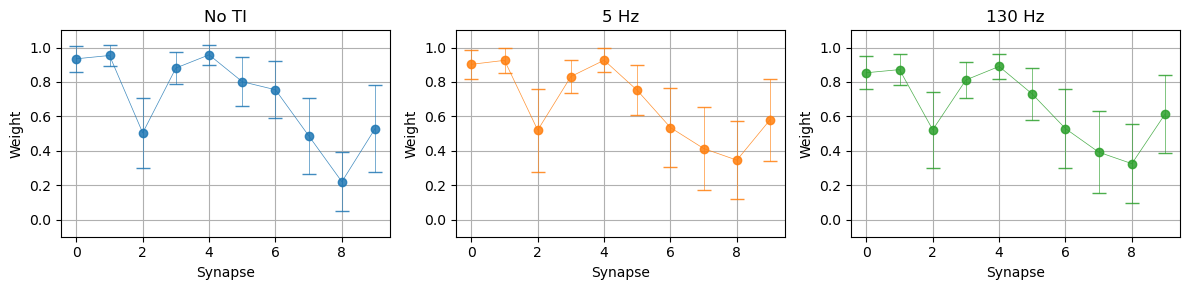

In [40]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))

for j, filetype in enumerate(["no_ti/0", "1000/90_90_5", "1000/90_90_130"]):
    syn_weights = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{filetype}/synapse_weights.csv")

    stds = np.array(syn_weights.std()[2:])
    means = np.array(syn_weights.mean()[2:])
    synapses = np.arange(0, 10)

    axs[j].errorbar(synapses, means, yerr = stds, color = colors[j], capsize = 5, fmt='o-', linewidth = 0.5, alpha = 0.85)
    axs[j].set_xlabel("Synapse")
    axs[j].set_ylabel("Weight")
    axs[j].set_title(labels[j])
    axs[j].grid()
    axs[j].set_ylim(-0.1, 1.1)

fig.tight_layout()
plt.show()

So, TI doesn't seem to change the synapse dynamics. It depends on dendritic location and initial weight of the synapse. Let's look at the distribution of the final weight.

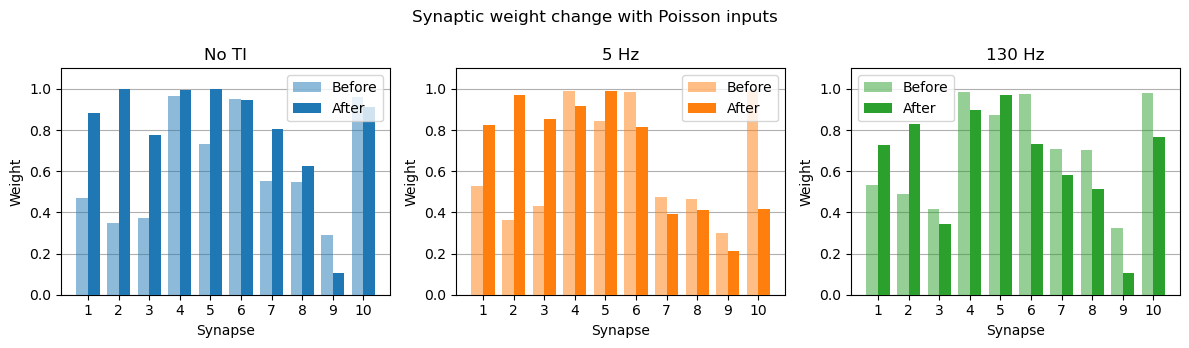

In [41]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3.5))

for j, filetype in enumerate(["no_ti/0", "1000/90_90_5", "1000/90_90_130"]):
    syn_weights = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{filetype}/synapse_weights.csv")

    initial_weights = syn_weights.iloc[0][2:]
    synapse_weights = syn_weights.iloc[-1][2:]
    synapses = np.arange(0, 10) + 1
    
    axs[j].grid(axis = "y", zorder = 0)
    axs[j].bar(synapses - 0.19, initial_weights, color = colors[j], zorder = 3, alpha = 0.5, width = 0.38, label = "Before")
    axs[j].bar(synapses + 0.19, synapse_weights, color = colors[j], zorder = 3, width = 0.38, label = "After")
    axs[j].set_ylim(0, 1.1)
    axs[j].set_title(labels[j])
    axs[j].set_xticks(synapses)
    axs[j].set_xticklabels(synapses)
    axs[j].legend()
    axs[j].set_xlabel("Synapse")
    axs[j].set_ylabel("Weight")

fig.suptitle("Synaptic weight change with Poisson inputs")
fig.tight_layout()
plt.show()

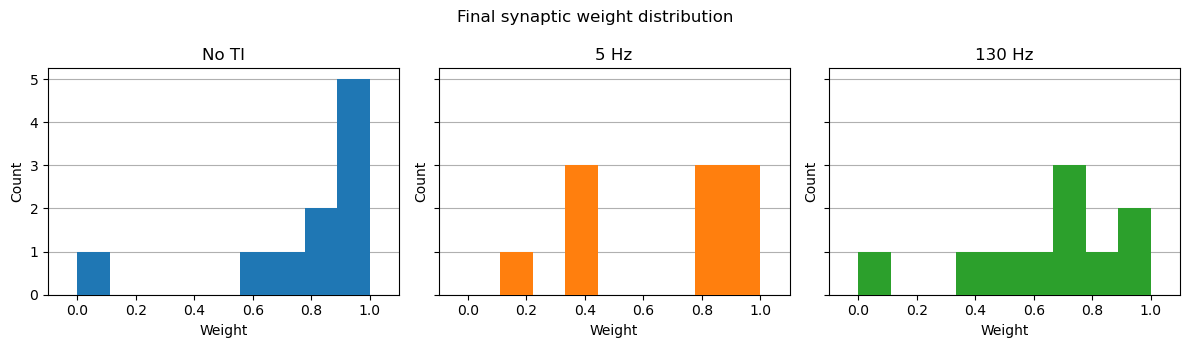

In [42]:
# ok, stop staring at it. distribution of final weights. GO

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3.5), sharey = True)

bin_edges = np.linspace(0, 1, num = 10)

for j, filetype in enumerate(["no_ti/0", "1000/90_90_5", "1000/90_90_130"]):
    syn_weights = pd.read_csv(f"output/temporal-interference/poisson/{idx}/{filetype}/synapse_weights.csv")

    synapse_weights = syn_weights.iloc[-1][2:]

    axs[j].grid(axis = "y", zorder = 0)
    axs[j].hist(synapse_weights, color = colors[j], zorder = 3, bins = bin_edges)
    axs[j].set_title(labels[j])
    axs[j].set_xlabel("Weight")
    axs[j].set_ylabel("Count")
    axs[j].set_xlim(-0.1, 1.1)

fig.suptitle("Final synaptic weight distribution")
fig.tight_layout()
plt.show()

### Does TI alter synaptic integration? (possibly a mechanism affecting synaptic plasticity, since that would affect firing patterns)

Synaptic integration might underlie how the EPSP signals are carried along the dendrites (e.g. if they come at a specific time during the wave, it could help them be carried towards the soma, or they might be slowed down) or if they arrive at a specific time at the axon hillock, they might lead to an AP with higher probability. 